In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import ollama


sys.path.append(os.path.abspath('..')) 


from src.processing.nlp_extractors import ScholarshipDataProcessor


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


tqdm.pandas(desc="Processing NLP Pipeline")

In [3]:
print(">>> Loading Raw Data...")
all_data = []

folder_path = '../data_Json' 

file_paths = glob.glob(os.path.join(folder_path, '*_scholarships_data*.json'))
for file_path in file_paths:
    try:
        df_temp = pd.read_json(file_path)
        df_temp['source_file'] = os.path.basename(file_path)
        all_data.append(df_temp)
    except Exception as e:
        print(f"Error loading {os.path.basename(file_path)}: {e}")

df_raw = pd.concat(all_data, ignore_index=True)
print(f" Total records loaded: {len(df_raw)}")
df_raw.head(2)

>>> Loading Raw Data...
 Total records loaded: 2526


,scholarship_name,country,degree_level,funding_type,awards_available,deadline,tags,description,scholarship_details,eligibility,application_process,application_link,source_file
0,International Titanium Association Scholarship...,USA,Cybersecurity,"$4,000",3,"May 14, 2026","[GPA, Selected Major(s), Current Year in Schoo...","The International Titanium Association, a non-...",N/A,N/A,N/A,https://www.scholarships.com/scholarships/inte...,cybersecurity_scholarships_data.json
1,Eye-Bank for Sight Restoration STEM Scholarship,USA,Cybersecurity,"$3,000",1,"May 15, 2026","[State Selection, Selected Major(s), Current Y...",The Eye-Bank together with the Fabian family c...,"$3,000 scholarship awarded annually\nOpen to u...",Must reside in The Eye-Bank’s service area: Ne...,Visit www.eyedonation.org/scholarship/stem to ...,https://www.scholarships.com/scholarships/eye-...,cybersecurity_scholarships_data.json


### funding_type & degree_level	

In [4]:
print(">>> Initializing the NLP Processor...")
processor = ScholarshipDataProcessor(use_zero_shot=False)

print(">>> Extracting Funding Data...")
df_raw[['funding_category', 'funding_amount']] = df_raw.progress_apply(processor.process_funding, axis=1)

print(">>> Extracting Degree Levels...")
df_raw['academic_level'] = df_raw.progress_apply(processor.process_degree_level, axis=1)['academic_level']

print(">>> Extracting Academic Majors via LLM...")
df_raw['academic_major'] = df_raw.progress_apply(processor.process_academic_major, axis=1)['academic_major']

print("Processing Complete!")

INFO: Initializing NLP Models...


>>> Initializing the NLP Processor...


INFO: Initializing LLM Client...


>>> Extracting Funding Data...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

...

Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

>>> Extracting Academic Majors via LLM...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST 

Processing Complete!


In [5]:
total_rows = len(df_raw)

unspecified_level = (df_raw['academic_level'] == 'Unspecified').sum()
unspecified_major = (df_raw['academic_major'] == 'Unspecified').sum()
unspecified_funding = (df_raw['funding_category'] == 'Variable / Unspecified').sum()

print("--- Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Academic Level Extraction Failure: {unspecified_level} records ({(unspecified_level/total_rows)*100:.1f}%)")
print(f"Academic Major Extraction Failure: {unspecified_major} records ({(unspecified_major/total_rows)*100:.1f}%)")
print(f"Funding Category Extraction Failure: {unspecified_funding} records ({(unspecified_funding/total_rows)*100:.1f}%)")

if unspecified_level > 0:
    print("\n--- Sample of Failed Academic Levels ---")
    display(df_raw[df_raw['academic_level'] == 'Unspecified'][['scholarship_name', 'description']].head())

if unspecified_major > 0:
    print("\n--- Sample of Failed Academic Majors ---")
    display(df_raw[df_raw['academic_major'] == 'Unspecified'][['scholarship_name', 'description']].head())

--- Extraction Quality Report ---
Total Processed: 2526
Academic Level Extraction Failure: 169 records (6.7%)
Academic Major Extraction Failure: 106 records (4.2%)
Funding Category Extraction Failure: 166 records (6.6%)

--- Sample of Failed Academic Levels ---


,scholarship_name,description
0,International Titanium Association Scholarship...,"The International Titanium Association, a non-..."
4,Reason One Mentorship and Scholarship Program,The Reason One Mentorship & Scholarship Progra...
6,Betty Stevens-Frecknall Scholarship,The Betty Stevens-Frecknall Scholarship is a p...
8,Project STEM Heroes Scholarship,"""You are the solution."" Inspired by the movie ..."
9,SBB Research Group STEM Scholarship,The SBB Research Group STEM Scholarship encour...



--- Sample of Failed Academic Majors ---


,scholarship_name,description
56,LinkedIn Possibilities in Tech Scholarship,"At LinkedIn, one of our core values is to “Dre..."
71,Tailhook Educational Foundation (TEF) Scholars...,The Tailhook Educational Foundation (TEF) is a...
83,Asama Coldwater Manufacturing (ACM) Georgia Sc...,To be eligible for the Asama Coldwater Manufac...
84,Brown Hudner Navy Scholarship,Inspired by the true story of Jesse Brown and ...
98,LNESC Ford Driving Dreams Scholarship,The Ford Driving Dreams Scholarship Program is...


In [6]:
import textwrap

print(">>> AI Major Extraction Quality Assurance (QA) Sample <<<\n")

extracted_majors = df_raw[~df_raw['academic_major'].isin(['Unspecified', 'All Disciplines'])]

qa_sample = extracted_majors.sample(5)

for index, row in qa_sample.iterrows():
    print(f"Scholarship: {row['scholarship_name']}")
    print(f"Extracted Major: {row['academic_major']}")
    
    context = str(row.get('description', '')) + " " + str(row.get('scholarship_details', ''))
    
    short_context = textwrap.shorten(context, width=400, placeholder=" ...")
    print(f"Context Snippet: \n{short_context}")
    print("-" * 80)

>>> AI Major Extraction Quality Assurance (QA) Sample <<<

Scholarship: DLR-DAAD Research Fellowship Programme (Syria - Undergraduates)
Extracted Major: Aeronautics, Space, Energy, Transportation
Context Snippet: 
'DLR-DAAD Research Fellowships' is a programme implemented by the 'German Aerospace Center' (DLR) and the 'German Academic Exchange Service' (DAAD). DLR is Germany’s national research centre for aeronautics and space. Its extensive research and development work in Aeronautics, Space, Energy and Transport is integrated into national and international cooperative ventures. As Germany’s space ...
--------------------------------------------------------------------------------
Scholarship: Alexander von Humboldt Foundation: International Climate Protection Fellowship (Egypt - Graduates)
Extracted Major: natural or engineering sciences, legal, economic, health-related, societal aspects of climate change
Context Snippet: 
--- Programme Description --- The International Climate Prot

/tmp/ipykernel_27802/1785376926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='academic_level', ax=axes[0], palette="viridis", order=df_raw['academic_level'].value_counts().index)
/tmp/ipykernel_27802/1785376926.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw[df_raw['academic_major'].isin(top_majors)], y='academic_major', ax=axes[1], palette="magma", order=top_majors)
/tmp/ipykernel_27802/1785376926.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='funding_category', ax=axes[2], 

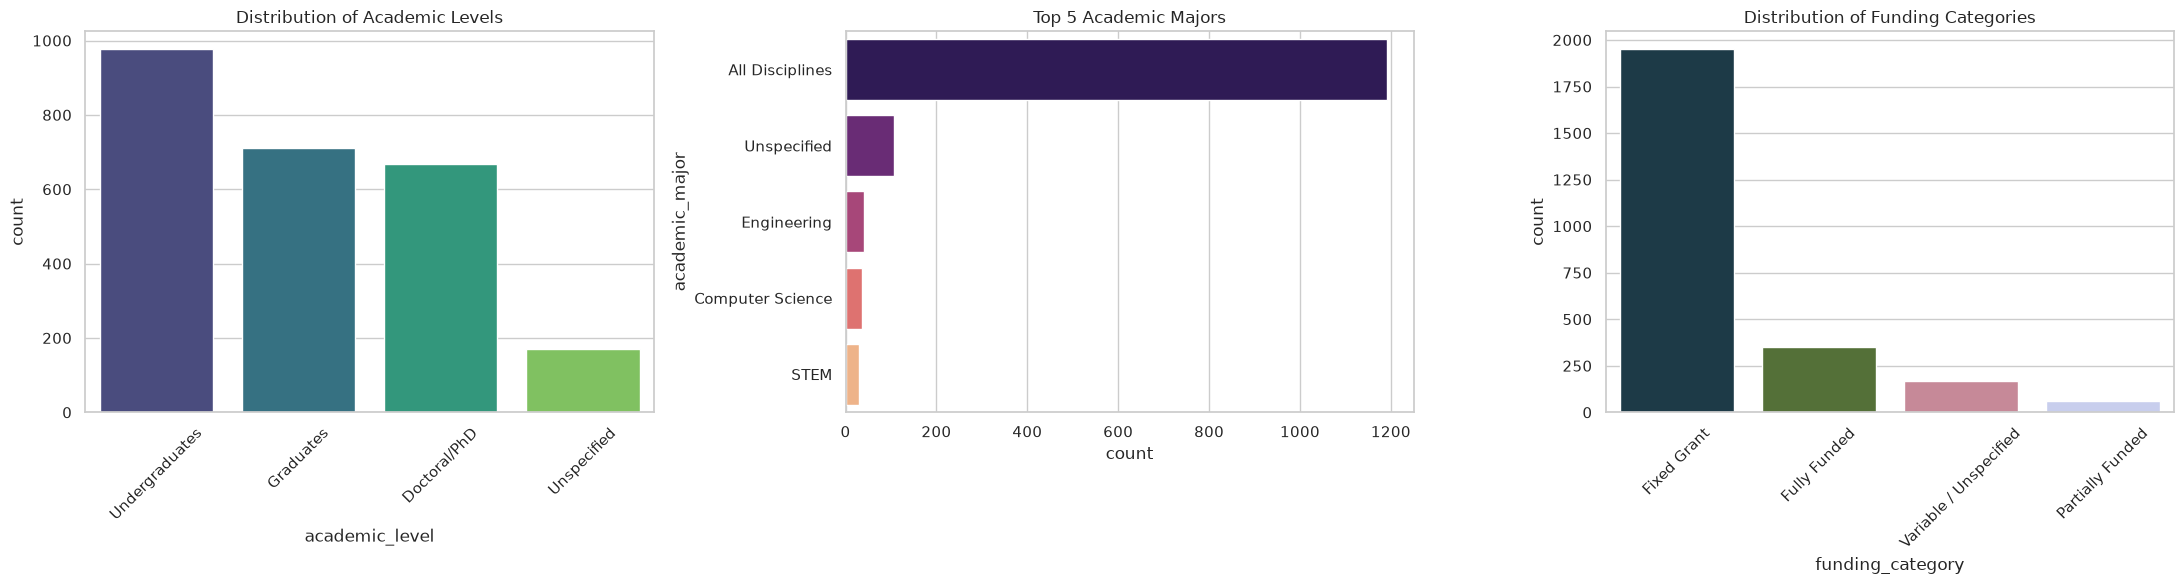

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))


sns.countplot(data=df_raw, x='academic_level', ax=axes[0], palette="viridis", order=df_raw['academic_level'].value_counts().index)
axes[0].set_title('Distribution of Academic Levels')
axes[0].tick_params(axis='x', rotation=45)


top_majors = df_raw['academic_major'].value_counts().nlargest(5).index
sns.countplot(data=df_raw[df_raw['academic_major'].isin(top_majors)], y='academic_major', ax=axes[1], palette="magma", order=top_majors)
axes[1].set_title('Top 5 Academic Majors')


sns.countplot(data=df_raw, x='funding_category', ax=axes[2], palette="cubehelix", order=df_raw['funding_category'].value_counts().index)
axes[2].set_title('Distribution of Funding Categories')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
print("--- 1. Academic Level Distribution ---")

level_dist = df_raw['academic_level'].value_counts()
level_pct = df_raw['academic_level'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': level_dist, 'Percentage %': level_pct.round(2)})
display(dist_df)

print("--- 1. Academic Major Distribution ---")

major_dist = df_raw['academic_major'].value_counts()
major_pct = df_raw['academic_major'].value_counts(normalize=True) * 100
dist_major_df = pd.DataFrame({'Count': major_dist, 'Percentage %': major_pct.round(2)})
display(dist_major_df)

print("\n--- 2. Funding Category Distribution ---")

funding_dist = df_raw['funding_category'].value_counts()
funding_pct = df_raw['funding_category'].value_counts(normalize=True) * 100
dist_funding_df = pd.DataFrame({'Count': funding_dist, 'Percentage %': funding_pct.round(2)})
display(dist_funding_df)

--- 1. Academic Level Distribution ---


,Count,Percentage %
academic_level,,
Undergraduates,976,38.64
Graduates,712,28.19
Doctoral/PhD,669,26.48
Unspecified,169,6.69


--- 1. Academic Major Distribution ---


,Count,Percentage %
academic_major,,
All Disciplines,1191,47.15
Unspecified,106,4.20
Engineering,40,1.58
Computer Science,37,1.46
STEM,29,1.15
...,...,...
"visual communication, photography, illustration, graphic design",1,0.04
"marketing, advertising, web development, graphic design, journalism, creative writing, entrepreneurship",1,0.04
"Technology-related courses, training",1,0.04



--- 2. Funding Category Distribution ---


,Count,Percentage %
funding_category,,
Fixed Grant,1949,77.16
Fully Funded,351,13.90
Variable / Unspecified,166,6.57
Partially Funded,60,2.38


In [9]:
print("--- QA: Academic Level Extraction Verification ---")

valid_levels = df_raw[df_raw['academic_level'] != 'Unspecified'].copy()


sample_levels = valid_levels.sample(frac=1, random_state=42).groupby('academic_level').head(20)


display(sample_levels[['scholarship_name', 'description', 'academic_level', 'academic_major','tags']])

print("\n--- QA: Funding Extraction Verification ---")

valid_funding = df_raw[df_raw['funding_category'] != 'Variable / Unspecified'].copy()


sample_funding = valid_funding.sample(frac=1, random_state=42).groupby('funding_category').head(10)


display(sample_funding[['funding_type', 'funding_category', 'funding_amount']])

--- QA: Academic Level Extraction Verification ---


,scholarship_name,description,academic_level,academic_major,tags
1697,Evangelisches Studienwerk: Scholarship for Doc...,---\nProgramme Description\n---\nEvery year th...,Undergraduates,All Disciplines,"[DAAD, Jordan, Undergraduates, Germany]"
1120,Cusanuswerk: Undergraduate and Postgraduate Fe...,---\nProgramme Description\n---\nThe Cusanuswe...,Doctoral/PhD,All Disciplines,"[DAAD, Syria, Doctoral candidates/PhD students..."
1651,Country-related cooperation programme with Col...,Graduates receive grants to complete a Master'...,Doctoral/PhD,All Disciplines,"[DAAD, Jordan, Doctoral candidates/PhD student..."
2174,National Videogame Museum Scholarships,The National Videogame Museum offers five dist...,Undergraduates,"Computer Science, Technology","[GPA, Gender, Selected Major(s), Current Year ..."
226,DAAD-TEV-Master's degree scholarships (Saudi A...,Offered in cooperation with the Turkish educat...,Doctoral/PhD,All Disciplines,"[DAAD, Saudi Arabia, Doctoral candidates/PhD s..."
1845,ERP Study Scholarships for Graduates of Econom...,,Graduates,Economics and Business Administration,"[DAAD, Saudi Arabia, Graduates, Germany]"
1184,Research Grants in Germany (Saudi Arabia - Und...,The research grant offers the opportunity to r...,Undergraduates,All Disciplines,"[DAAD, Saudi Arabia, Undergraduates, Germany]"
479,German Studies Research Grant (Egypt - Undergr...,The aim of the research grant is to fund and e...,Undergraduates,German Cultural Studies,"[DAAD, Egypt, Undergraduates, Germany]"
1702,Evangelisches Studienwerk: Scholarship for Doc...,---\nProgramme Description\n---\nEvery year th...,Doctoral/PhD,All Disciplines,"[DAAD, Saudi Arabia, Doctoral candidates/PhD s..."
1530,Rosa Luxemburg Foundation: Scholarship Program...,---\nProgramme Description\n---\nThe RLF is a ...,Graduates,All Disciplines,"[DAAD, Jordan, Graduates, Germany]"



--- QA: Funding Extraction Verification ---


,funding_type,funding_category,funding_amount
650,Fully/Partially Funded (Check Details),Fixed Grant,"30,000 eur"
529,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
2366,"$1,000",Fixed Grant,"$1,000"
2113,Fully/Partially Funded (Check Details),Fully Funded,NaN
1706,Fully/Partially Funded (Check Details),Fixed Grant,855 eur
226,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
1725,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
260,Fully/Partially Funded (Check Details),Fixed Grant,500 eur
1235,Fully/Partially Funded (Check Details),Fixed Grant,"1,750 eur"
697,Fully/Partially Funded (Check Details),Fixed Grant,"1,800 eur"


### country

In [10]:
print(">>> Extracting Host Countries and Eligible Nationalities...")
df_raw[['host_country', 'eligible_nationality']] = df_raw.progress_apply(processor.process_country, axis=1)
print("Extraction Complete!")

>>> Extracting Host Countries and Eligible Nationalities...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

Extraction Complete!


In [11]:
total_rows = len(df_raw)

# Calculate missing or default values
unspecified_host = (df_raw['host_country'] == 'Unspecified').sum()
international_nat = (df_raw['eligible_nationality'] == 'International / All').sum()

print("--- Location Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Host Country Not Found (Unspecified): {unspecified_host} records ({(unspecified_host/total_rows)*100:.1f}%)")
print(f"Eligible Nationality (Defaulted to International): {international_nat} records ({(international_nat/total_rows)*100:.1f}%)")

# Display a sample of records where host country failed
if unspecified_host > 0:
    print("\n--- Sample of Failed Host Country Extractions ---")
    display(df_raw[df_raw['host_country'] == 'Unspecified'][['scholarship_name', 'country', 'description']].head())

--- Location Extraction Quality Report ---
Total Processed: 2526
Host Country Not Found (Unspecified): 0 records (0.0%)
Eligible Nationality (Defaulted to International): 488 records (19.3%)


In [12]:
print("--- QA: Host Country and Nationality Verification ---")

# Filter out rows where host country is unspecified to verify successful extractions
valid_locations = df_raw[df_raw['host_country'] != 'Germany'].copy()

# Take a randomized sample grouped by host country
sample_locations = valid_locations.sample(frac=1, random_state=42).groupby('host_country').head(10)

# Display the raw country column alongside the extracted features
display(sample_locations[['scholarship_name', 'country', 'host_country', 'eligible_nationality']].head(15))

--- QA: Host Country and Nationality Verification ---


,scholarship_name,country,host_country,eligible_nationality
2214,National Defense Science & Engineering Graduat...,USA,USA,International / All
131,New Futures Scholars Program,USA,USA,International / All
149,Susan Lawrence Soldier For Life Scholarship,USA,USA,International / All
2236,Amazon Future Engineer Scholarship,USA,USA,Washington
84,Brown Hudner Navy Scholarship,USA,USA,International / All
2368,Andrew Budraitis Foundation Lehigh Valley Scho...,USA,USA,the Lehigh Valley
6,Betty Stevens-Frecknall Scholarship,USA,USA,International / All
2468,TEDS Faithful Future Scholarship,USA,USA,International / All
2508,BHW Scholarship,USA,USA,International / All
55,Barry M. Goldwater Scholarship & Excellence in...,USA,USA,International / All


/tmp/ipykernel_27802/3365733669.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.values, y=top_hosts.index, ax=axes[0], palette="Blues_d")
/tmp/ipykernel_27802/3365733669.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nats.values, y=top_nats.index, ax=axes[1], palette="Greens_d")


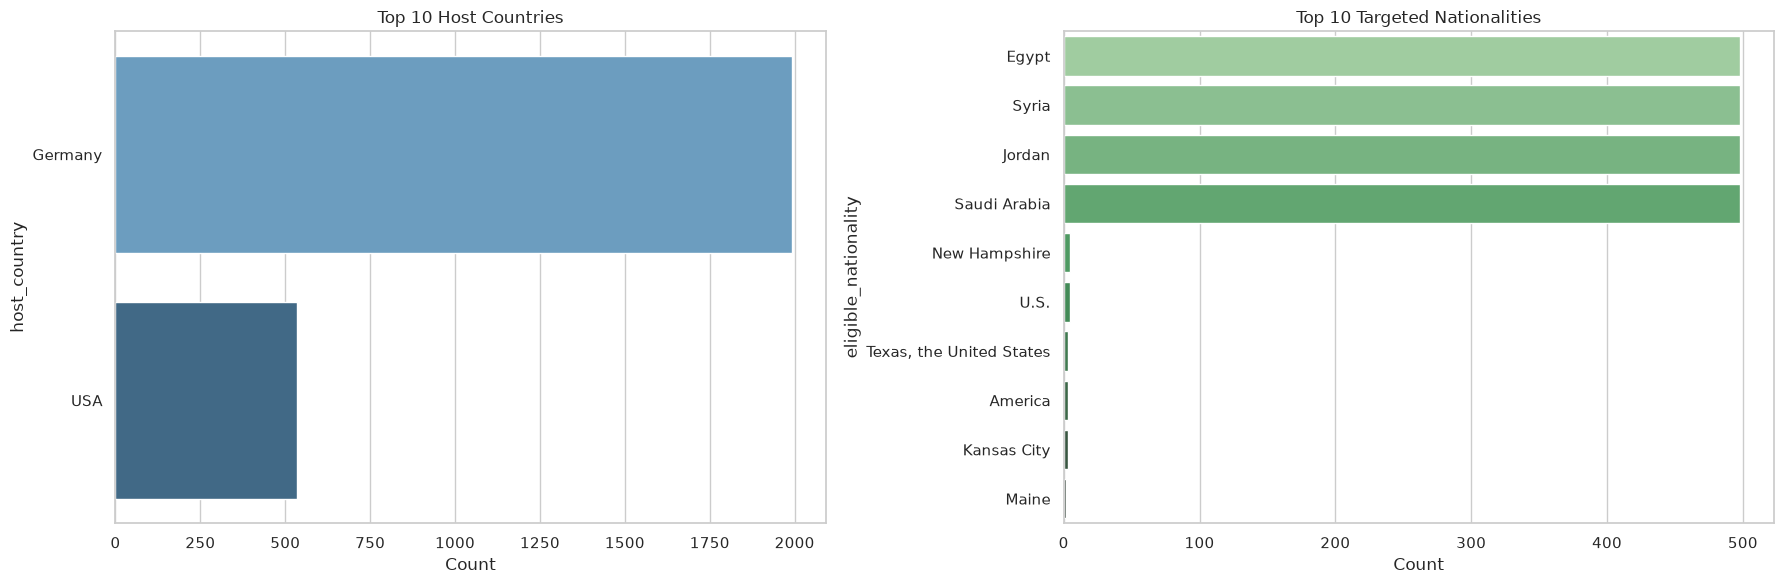

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Top 10 Host Countries
# Exclude 'Unspecified' for a cleaner chart
top_hosts = df_raw[df_raw['host_country'] != 'Unspecified']['host_country'].value_counts().nlargest(10)
sns.barplot(x=top_hosts.values, y=top_hosts.index, ax=axes[0], palette="Blues_d")
axes[0].set_title('Top 10 Host Countries')
axes[0].set_xlabel('Count')

# 2. Top 10 Restricted Eligible Nationalities
# Exclude 'International / All' to see which specific countries are targeted
top_nats = df_raw[df_raw['eligible_nationality'] != 'International / All']['eligible_nationality'].value_counts().nlargest(10)
if not top_nats.empty:
    sns.barplot(x=top_nats.values, y=top_nats.index, ax=axes[1], palette="Greens_d")
    axes[1].set_title('Top 10 Targeted Nationalities')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No Restricted Nationalities Found', horizontalalignment='center', verticalalignment='center')
    axes[1].set_title('Top 10 Targeted Nationalities')

plt.tight_layout()
plt.show()

### deadline

In [14]:
df_raw['deadline'].value_counts()

deadline
Not Specified                                                                                                                                                                                                                                                                                                                                1512
Varies                                                                                                                                                                                                                                                                                                                                         51
May 01, 2027                                                                                                                                                                                                                                                                                                               

In [15]:
import pandas as pd
import requests
import ollama
from src.processing.nlp_extractors import ScholarshipDataProcessor

print(">>> Initializing updated ScholarshipDataProcessor (Ollama Edition)...")
processor = ScholarshipDataProcessor(use_zero_shot=False)

# ---------------------------------------------------------
# NEW: Sanity check to ensure Ollama and Qwen are running
# ---------------------------------------------------------
print(">>> Checking Local LLM Status...")
try:
    response = requests.get("http://localhost:11434/api/tags", timeout=5)
    if response.status_code == 200:
        if 'qwen2.5:7b' in response.text or 'qwen2.5' in response.text:
            print("SUCCESS: Ollama is running and Qwen-2.5 is available.")
        else:
            print("WARNING: Ollama is running, but Qwen-2.5 was not found. Please run: 'ollama run qwen2.5:7b' in terminal.")
    else:
        print(f"WARNING: Ollama returned unexpected status code: {response.status_code}")
except requests.ConnectionError:
    print("ERROR: Ollama is not running! Please open the Ollama application before proceeding.")

# ---------------------------------------------------------
# Execution and Analysis
# ---------------------------------------------------------
print("\n>>> Extracting Deadlines with Hybrid Engine...")
df_raw['standardized_deadline'] = df_raw.progress_apply(processor.process_deadline, axis=1)['standardized_deadline']

# Calculate metrics
total_rows = len(df_raw)
specified = (df_raw['standardized_deadline'] != 'Not Specified').sum()
missing = total_rows - specified

# Print Quality Report
print("\n--- Deadline Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Dates Successfully Standardized: {specified} ({(specified/total_rows)*100:.1f}%)")
print(f"Remaining Missing/Varies: {missing} ({(missing/total_rows)*100:.1f}%)")

# Comprehensive Before & After Analysis
print("\n--- Comprehensive Analysis: Before & After Mapping ---")

# Group by the original deadline and the new standardized deadline to show all variations
mapping_analysis = df_raw.groupby(['deadline', 'standardized_deadline']).size().reset_index(name='frequency_count')

# Sort by frequency to see the most common transformations first
mapping_analysis = mapping_analysis.sort_values(by='frequency_count', ascending=False)

# Set Pandas options to display the full text and more rows for a comprehensive view
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 150)

# Display the complete mapping analysis
display(mapping_analysis)

# Reset Pandas view options to avoid affecting other cells
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

INFO: Initializing NLP Models...


>>> Initializing updated ScholarshipDataProcessor (Ollama Edition)...


INFO: Initializing LLM Client...


>>> Checking Local LLM Status...
SUCCESS: Ollama is running and Qwen-2.5 is available.

>>> Extracting Deadlines with Hybrid Engine...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST 


--- Deadline Extraction Quality Report ---
Total Processed: 2526
Dates Successfully Standardized: 1091 (43.2%)
Remaining Missing/Varies: 1435 (56.8%)

--- Comprehensive Analysis: Before & After Mapping ---


,deadline,standardized_deadline,frequency_count
169,Not Specified,Not Specified,1076
152,Not Specified,2023-03-01,50
192,Varies,Not Specified,49
145,Not Specified,2023-01-15,36
128,"May 01, 2027",2027-05-01,33
...,...,...,...
180,"October 28, 2026",2026-10-28,1
177,"October 06, 2026",2026-10-06,1
182,"October 31, 2026",2026-10-31,1
185,"September 15, 2026",2026-09-15,1


In [16]:

mapping_analysis.to_csv("deadline_mapping_grouped.csv", index=False)
print("Saved grouped mapping to: deadline_mapping_grouped.csv")


qa_df = df_raw[['scholarship_name', 'deadline', 'standardized_deadline']]
qa_df.to_csv("deadline_qa_full_comparison.csv", index=False)
print("Saved full row-by-row comparison to: deadline_qa_full_comparison.csv")

Saved grouped mapping to: deadline_mapping_grouped.csv
Saved full row-by-row comparison to: deadline_qa_full_comparison.csv


In [17]:
import pandas as pd

print(">>> Analyzing Expired vs. Active Scholarships <<<\n")

# 1. تحويل عمود التواريخ إلى نوع (Datetime) للتمكن من المقارنة الرياضية
# القيم 'Not Specified' ستتحول تلقائياً إلى NaT (Not a Time)
df_raw['parsed_date'] = pd.to_datetime(df_raw['standardized_deadline'], errors='coerce')

# 2. تحديد تاريخ اليوم للمقارنة
today = pd.Timestamp.now()

# 3. إنشاء عمود 'is_expired' للفلترة المستقبلية في الـ RAG
# إذا كان التاريخ أصغر من اليوم فهو منتهي (True)، غير ذلك فهو (False)
df_raw['is_expired'] = df_raw['parsed_date'] < today

# 4. حساب الإحصائيات
total_rows = len(df_raw)
has_date = df_raw['parsed_date'].notna().sum()
expired_count = (df_raw['parsed_date'] < today).sum()
active_count = (df_raw['parsed_date'] >= today).sum()
missing_count = df_raw['parsed_date'].isna().sum()

# 5. طباعة التقرير
print("--- Deadline Status Report ---")
print(f"Total Scholarships: {total_rows}")
print(f"Without clear dates (Not Specified): {missing_count} ({(missing_count/total_rows)*100:.1f}%)")
print("-" * 30)
print(f"Total with valid dates: {has_date}")
print(f" Expired / Old Deadlines: {expired_count} ({(expired_count/has_date)*100:.1f}% of dated scholarships)")
print(f" Active / Future Deadlines: {active_count} ({(active_count/has_date)*100:.1f}% of dated scholarships)")

# عرض عينة للمنح القديمة للتحقق
print("\n--- Sample of Expired Scholarships ---")
display(df_raw[df_raw['is_expired'] == True][['scholarship_name', 'standardized_deadline']].head())

>>> Analyzing Expired vs. Active Scholarships <<<

--- Deadline Status Report ---
Total Scholarships: 2526
Without clear dates (Not Specified): 1473 (58.3%)
------------------------------
Total with valid dates: 1053
 Expired / Old Deadlines: 654 (62.1% of dated scholarships)
 Active / Future Deadlines: 399 (37.9% of dated scholarships)

--- Sample of Expired Scholarships ---


,scholarship_name,standardized_deadline
0,International Titanium Association Scholarship...,2026-05-14
1,Eye-Bank for Sight Restoration STEM Scholarship,2026-05-15
2,Nutanix Women in Technology Scholarships,2026-05-15
3,Parle Endeavors Scholarship,2026-05-15
4,Reason One Mentorship and Scholarship Program,2026-05-22


In [18]:
import pandas as pd
import numpy as np

print(">>> Updating Scholarship Status Categorization <<<")

df_raw['parsed_date'] = pd.to_datetime(df_raw['standardized_deadline'], errors='coerce')
today = pd.Timestamp.now()

conditions = [
    df_raw['parsed_date'].isna(),
    df_raw['parsed_date'] < today,
    df_raw['parsed_date'] >= today
]

choices = ['Rolling/Unspecified', 'Expired', 'Active']

df_raw['scholarship_status'] = np.select(conditions, choices, default='Unknown')

status_counts = df_raw['scholarship_status'].value_counts()
print("\n--- Final Status Distribution ---")
print(status_counts.to_string())

print("\nSaved categorization to DataFrame successfully.")

>>> Updating Scholarship Status Categorization <<<

--- Final Status Distribution ---
scholarship_status
Rolling/Unspecified    1473
Expired                 654
Active                  399

Saved categorization to DataFrame successfully.


In [19]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   scholarship_name       2526 non-null   str           
 1   country                2526 non-null   str           
 2   degree_level           2526 non-null   str           
 3   funding_type           2526 non-null   str           
 4   awards_available       2526 non-null   str           
 5   deadline               2526 non-null   str           
 6   tags                   2526 non-null   object        
 7   description            2526 non-null   str           
 8   scholarship_details    2526 non-null   str           
 9   eligibility            2526 non-null   str           
 10  application_process    2526 non-null   str           
 11  application_link       2526 non-null   str           
 12  source_file            2526 non-null   str           
 13  funding_catego

### application_process

In [20]:
print(">>> Processing 'application_process' for Database Storage (Fallback Imputation)...")

df_raw['application_process'] = df_raw['application_process'].fillna('').astype(str).str.strip()

useless_vals = ['nan', 'none', 'n/a', 'not specified', 'tba', '']
fallback_message = "Please visit the official scholarship website for detailed application instructions and requirements."

missing_condition = (
    df_raw['application_process'].str.lower().isin(useless_vals) | 
    (df_raw['application_process'].str.split().str.len() < 10)
)

df_raw.loc[missing_condition, 'application_process'] = fallback_message

fixed_count = missing_condition.sum()
print(f"Successfully imputed {fixed_count} missing or useless application processes with the safe fallback message.")

>>> Processing 'application_process' for Database Storage (Fallback Imputation)...
Successfully imputed 1712 missing or useless application processes with the safe fallback message.


### text_columns

In [21]:
import pandas as pd
import re

print(">>> Running Text Quality Diagnostics for RAG Preparation <<<\n")

text_columns = [
    'scholarship_name', 'description', 'scholarship_details', 
    'eligibility', 'application_process'
]

diagnostic_results = []

for col in text_columns:
    # 1. Check missing or empty strings
    missing_count = df_raw[col].isna().sum() + (df_raw[col].astype(str).str.strip() == '').sum()
    
    # 2. Check for HTML presence
    html_pattern = re.compile(r'<[^>]+>')
    has_html_count = df_raw[col].astype(str).apply(lambda x: bool(html_pattern.search(x))).sum()
    
    # 3. Check for excessive whitespaces or newlines
    whitespace_pattern = re.compile(r'\s{3,}|\n{2,}')
    has_noise_count = df_raw[col].astype(str).apply(lambda x: bool(whitespace_pattern.search(x))).sum()
    
    # 4. Check average word count (to detect useless short texts)
    avg_words = df_raw[col].astype(str).apply(lambda x: len(x.split())).mean()
    
    diagnostic_results.append({
        'Column': col,
        'Missing / Empty': missing_count,
        'Contains HTML': has_html_count,
        'Whitespace Noise': has_noise_count,
        'Avg Word Count': round(avg_words, 1)
    })

diag_df = pd.DataFrame(diagnostic_results)

pd.set_option('display.max_columns', None)
print("--- Text Columns Diagnostic Report ---")
display(diag_df)

>>> Running Text Quality Diagnostics for RAG Preparation <<<



--- Text Columns Diagnostic Report ---


,Column,Missing / Empty,Contains HTML,Whitespace Noise,Avg Word Count
0,scholarship_name,0,0,0,10.7
1,description,24,0,1,48.9
2,scholarship_details,0,24,12,325.7
3,eligibility,36,0,0,76.0
4,application_process,0,0,54,114.4


In [22]:
import pandas as pd
import re

print(">>> Advanced Text Diagnostics Engine (Read-Only) <<<\n")

text_cols = ['description', 'scholarship_details', 'eligibility', 'application_process']
diagnostic_stats = []

# Define regex patterns for structural and whitespace issues
patterns = {
    'broken_bullets': re.compile(r'[•-]\s*\n'),
    'manual_separators': re.compile(r'-{3,}|={3,}|\*{3,}'),
    'excessive_newlines': re.compile(r'\n{3,}'),
    'non_breaking_spaces': re.compile(r'\xa0'),
    'html_tags': re.compile(r'<[^>]+>')
}

dead_text_vals = ['none', 'n/a', 'not specified', 'tba', '']

for col in text_cols:
    stats = {'Column_Name': col}
    
    col_data = df_raw[col].fillna('').astype(str)
    
    stats['Broken_Bullets'] = col_data.apply(lambda x: bool(patterns['broken_bullets'].search(x))).sum()
    stats['Manual_Separators'] = col_data.apply(lambda x: bool(patterns['manual_separators'].search(x))).sum()
    stats['HTML_Tags'] = col_data.apply(lambda x: bool(patterns['html_tags'].search(x))).sum()
    
    stats['Excessive_Newlines'] = col_data.apply(lambda x: bool(patterns['excessive_newlines'].search(x))).sum()
    stats['Non_Breaking_Spaces'] = col_data.apply(lambda x: bool(patterns['non_breaking_spaces'].search(x))).sum()
    
    stats['Dead_Text'] = col_data.apply(lambda x: x.strip().lower() in dead_text_vals or (0 < len(x.strip()) < 15)).sum()
    
    diagnostic_stats.append(stats)

diag_df = pd.DataFrame(diagnostic_stats)

# Check for Redundancy: Description duplicated inside Details
desc_data = df_raw['description'].fillna('').astype(str).str.strip()
details_data = df_raw['scholarship_details'].fillna('').astype(str).str.strip()

overlap_count = 0
for d, det in zip(desc_data, details_data):
    if len(d) > 20 and d in det:
        overlap_count += 1

print("--- Text Quality Diagnostic Report ---")
display(diag_df)

print("\n--- Severe Redundancy Alert ---")
print(f"Total rows where 'description' is completely duplicated inside 'scholarship_details': {overlap_count}")
print(f"Impact: {round((overlap_count/len(df_raw))*100, 1)}% of the dataset suffers from context duplication.")

>>> Advanced Text Diagnostics Engine (Read-Only) <<<

--- Text Quality Diagnostic Report ---


,Column_Name,Broken_Bullets,Manual_Separators,HTML_Tags,Excessive_Newlines,Non_Breaking_Spaces,Dead_Text
0,description,1104,1104,0,0,12,24
1,scholarship_details,1992,1992,24,0,60,232
2,eligibility,1536,1536,0,0,12,674
3,application_process,516,516,0,0,0,0



--- Severe Redundancy Alert ---
Total rows where 'description' is completely duplicated inside 'scholarship_details': 648
Impact: 25.7% of the dataset suffers from context duplication.


### Process

In [23]:
from src.processing.rag_formatter import RagDocumentBuilder

print(">>> Initializing RAG Formatter...")
rag_builder = RagDocumentBuilder()

print(">>> Building RAG Documents & Metadata...")
df_raw['rag_document'] = df_raw.apply(rag_builder.build_document, axis=1)
df_raw['rag_metadata'] = df_raw.apply(rag_builder.build_metadata, axis=1)

print(">>> RAG Formatting Complete!")

>>> Initializing RAG Formatter...
>>> Building RAG Documents & Metadata...


>>> RAG Formatting Complete!


In [24]:
import numpy as np

df_raw['rag_word_count'] = df_raw['rag_document'].apply(lambda x: len(str(x).split()))

empty_docs = (df_raw['rag_word_count'] == 0).sum()
huge_docs = (df_raw['rag_word_count'] > 800).sum()

print("--- RAG Document Statistical Analysis ---")
print(f"Total Documents: {len(df_raw)}")
print(f"Empty Documents (Zero extraction): {empty_docs} records")
print(f"Huge Documents (>800 words, needs chunking): {huge_docs} records\n")

print("--- Word Count Distribution ---")
print(df_raw['rag_word_count'].describe(percentiles=[.25, .5, .75, .90, .95]).round(1))

if empty_docs > 0:
    print("\n--- Warning: Empty Documents Detected ---")
    display(df_raw[df_raw['rag_word_count'] == 0][['scholarship_name', 'application_link']].head())

--- RAG Document Statistical Analysis ---
Total Documents: 2526
Empty Documents (Zero extraction): 0 records
Huge Documents (>800 words, needs chunking): 252 records

--- Word Count Distribution ---
count    2526.0
mean      423.6
std       334.6
min        29.0
25%       194.0
50%       353.0
75%       508.0
90%       799.5
95%      1343.0
max      1748.0
Name: rag_word_count, dtype: float64


In [25]:
print(">>> Semantic QA Inspection (Random Sample) <<<\n")

sample_df = df_raw[df_raw['rag_word_count'] > 50].sample(3)

for idx, row in sample_df.iterrows():
    print("=" * 80)
    print(f"METADATA CHECK:")
    for k, v in row['rag_metadata'].items():
        if k in ['scholarship_name', 'academic_level', 'scholarship_status']:
            print(f"  - {k}: {v}")
            
    print(f"\nDOCUMENT CONTENT (First 500 chars):")
    print("-" * 40)
    snippet = str(row['rag_document'])[:500]
    print(snippet + ("..." if len(str(row['rag_document'])) > 500 else ""))
    
    links_found = str(row['rag_document']).count('[LINK]')
    emails_found = str(row['rag_document']).count('[EMAIL]')
    print(f"\n[Sanitization Check] Replaced Links: {links_found} | Replaced Emails: {emails_found}")
    print("=" * 80 + "\n")

>>> Semantic QA Inspection (Random Sample) <<<

METADATA CHECK:
  - scholarship_name: Residential Fellowships at the Center for Advanced Internet Studies (CAIS) (Syria - Graduates)
  - academic_level: Graduates
  - scholarship_status: Rolling/Unspecified

DOCUMENT CONTENT (First 500 chars):
----------------------------------------
# Scholarship: Residential Fellowships at the Center for Advanced Internet Studies (CAIS) (Syria - Graduates)

**Application Link:** https://www2.daad.de/deutschland/stipendium/datenbank/en/21148-scholarship-database/?status=&origin=&subjectGrps=&daad=&intention=&q=&page=32&lang=en&sd=1&detail=10000622&page=32

## Scholarship Details
Programme Description
 
Are you researching the social effects of digitalisation? Do you want more freedom for your project and are interested in interdisciplinary ...

[Sanitization Check] Replaced Links: 1 | Replaced Emails: 0

METADATA CHECK:
  - scholarship_name: vCISO Cybersecurity Scholarship
  - academic_level: Undergradua

In [26]:
def validate_metadata_schema(meta):
    if not isinstance(meta, dict): return False
    for k, v in meta.items():
        if not isinstance(v, (str, int, float, bool)): return False
        if pd.isna(v) or v == 'nan': return False
    return True

df_raw['metadata_valid'] = df_raw['rag_metadata'].apply(validate_metadata_schema)
invalid_meta_count = (~df_raw['metadata_valid']).sum()

print("--- Metadata Schema Validation ---")
if invalid_meta_count == 0:
    print("SUCCESS: 100% of metadata dictionaries are valid and ready for ChromaDB.")
else:
    print(f"CRITICAL ERROR: {invalid_meta_count} records have invalid metadata structures.")

--- Metadata Schema Validation ---
SUCCESS: 100% of metadata dictionaries are valid and ready for ChromaDB.


In [27]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   scholarship_name       2526 non-null   str           
 1   country                2526 non-null   str           
 2   degree_level           2526 non-null   str           
 3   funding_type           2526 non-null   str           
 4   awards_available       2526 non-null   str           
 5   deadline               2526 non-null   str           
 6   tags                   2526 non-null   object        
 7   description            2526 non-null   str           
 8   scholarship_details    2526 non-null   str           
 9   eligibility            2526 non-null   str           
 10  application_process    2526 non-null   str           
 11  application_link       2526 non-null   str           
 12  source_file            2526 non-null   str           
 13  funding_catego

In [28]:
import os


output_dir = "../data_Json/processed"
output_file_json = os.path.join(output_dir, "master_scholarships_clean.json")

os.makedirs(output_dir, exist_ok=True)


df_raw.to_json(output_file_json, orient='records', indent=4)
print(f"Successfully saved clean data to: {output_file_json}")

/tmp/ipykernel_27802/3523941043.py:10: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df_raw.to_json(output_file_json, orient='records', indent=4)


Successfully saved clean data to: ../data_Json/processed/master_scholarships_clean.json
